In [1]:
#Cell 1: importera alla bibliotek som behövs i resten av notebooken
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, shapiro, levene, ttest_ind, mannwhitneyu

In [2]:
#Cell 2: hitta projektmappen och datafilen
project_folder = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
file_path = project_folder / "data" / "XXH2023_YRBS_Data.dat"

print("Projektmapp:", project_folder)
print("Datafil:", file_path)
print("Finns filen?", file_path.exists())

Projektmapp: c:\Users\mahta\aidev\yrbs-sleep-social-media-analysis
Datafil: c:\Users\mahta\aidev\yrbs-sleep-social-media-analysis\data\XXH2023_YRBS_Data.dat
Finns filen? True


In [3]:
#Cell 3: läs in Q80 och Q85 från ASCII-filen
df = pd.read_fwf(
    file_path,
    colspecs=[(110, 111), (115, 116)],
    header=None,
    names=["Q80", "Q85"],
    dtype=str
)

df.head()

,Q80,Q85
0,6,3
1,4,5
2,8,1
3,8,4
4,6,3


In [4]:
#Cell 4: rensa data och översätt koderna till begriplig text
df = df.replace(r"^\s*$", np.nan, regex=True)

df["Q80"] = pd.to_numeric(df["Q80"], errors="coerce")
df["Q85"] = pd.to_numeric(df["Q85"], errors="coerce")

social_media_map = {
    1: "I do not use social media",
    2: "A few times a month",
    3: "About once a week",
    4: "A few times a week",
    5: "About once a day",
    6: "Several times a day",
    7: "About once an hour",
    8: "More than once an hour"
}

sleep_map = {
    1: "4 or less hours",
    2: "5 hours",
    3: "6 hours",
    4: "7 hours",
    5: "8 hours",
    6: "9 hours",
    7: "10 or more hours"
}

df["social_media_label"] = df["Q80"].map(social_media_map)
df["sleep_label"] = df["Q85"].map(sleep_map)

df.head()

,Q80,Q85,social_media_label,sleep_label
0,6.0,3.0,Several times a day,6 hours
1,4.0,5.0,A few times a week,8 hours
2,8.0,1.0,More than once an hour,4 or less hours
3,8.0,4.0,More than once an hour,7 hours
4,6.0,3.0,Several times a day,6 hours


In [5]:
#Cell 5: skapa frekvenser där alla svarsalternativ visas, även om frekvens = 0
all_social_categories = list(social_media_map.values())
all_sleep_categories = list(sleep_map.values())

social_counts = (
    df["social_media_label"]
    .value_counts()
    .reindex(all_social_categories, fill_value=0)
)

sleep_counts = (
    df["sleep_label"]
    .value_counts()
    .reindex(all_sleep_categories, fill_value=0)
)

print("Social media counts:")
print(social_counts)

print("\nSleep counts:")
print(sleep_counts)

Social media counts:
social_media_label
I do not use social media    1082
A few times a month           406
About once a week             231
A few times a week            708
About once a day              904
Several times a day          5888
About once an hour           1181
More than once an hour       4803
Name: count, dtype: int64

Sleep counts:
sleep_label
4 or less hours     1666
5 hours             2562
6 hours             4342
7 hours             4865
8 hours             3009
9 hours              733
10 or more hours     264
Name: count, dtype: int64


In [6]:
#Cell 6: skapa numeriska analysvariabler och räkna mean, median, mode
social_numeric_map = {
    "I do not use social media": 1,
    "A few times a month": 2,
    "About once a week": 3,
    "A few times a week": 4,
    "About once a day": 5,
    "Several times a day": 6,
    "About once an hour": 7,
    "More than once an hour": 8
}

sleep_numeric_map = {
    "4 or less hours": 4,
    "5 hours": 5,
    "6 hours": 6,
    "7 hours": 7,
    "8 hours": 8,
    "9 hours": 9,
    "10 or more hours": 10
}

df["social_numeric"] = df["social_media_label"].map(social_numeric_map)
df["sleep_numeric"] = df["sleep_label"].map(sleep_numeric_map)

df_analysis = df.dropna(subset=["social_numeric", "sleep_numeric"]).copy()

print("Antal observationer totalt:", len(df))
print("Antal observationer i analysen:", len(df_analysis))

print("\nSocial media:")
print("Mean:", df_analysis["social_numeric"].mean())
print("Median:", df_analysis["social_numeric"].median())
print("Mode:", df_analysis["social_numeric"].mode()[0])

print("\nSleep:")
print("Mean:", df_analysis["sleep_numeric"].mean())
print("Median:", df_analysis["sleep_numeric"].median())
print("Mode:", df_analysis["sleep_numeric"].mode()[0])

Antal observationer totalt: 18914
Antal observationer i analysen: 13730

Social media:
Mean: 6.074581209031319
Median: 6.0
Mode: 6.0

Sleep:
Mean: 6.4565185724690455
Median: 7.0
Mode: 7.0


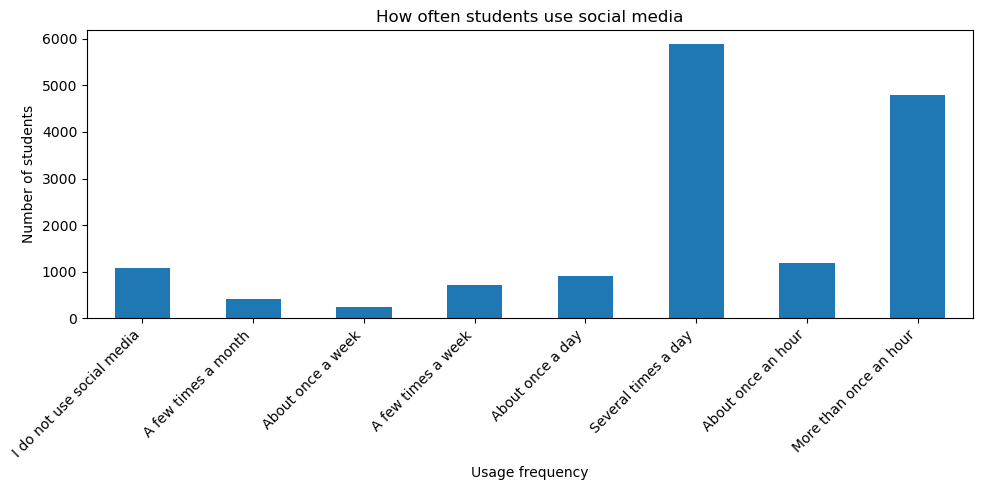

In [7]:
#Cell 7: stapeldiagram för social media där alla kategorier syns
plt.figure(figsize=(10, 5))
social_counts.plot(kind="bar")
plt.title("How often students use social media")
plt.xlabel("Usage frequency")
plt.ylabel("Number of students")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

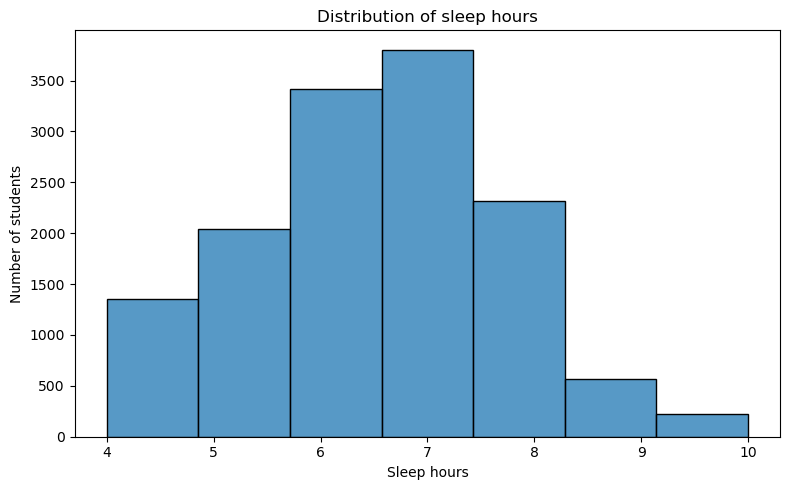

In [8]:
#Cell 8: histogram för sleep_numeric
plt.figure(figsize=(8, 5))
sns.histplot(data=df_analysis, x="sleep_numeric", bins=7)
plt.title("Distribution of sleep hours")
plt.xlabel("Sleep hours")
plt.ylabel("Number of students")
plt.tight_layout()
plt.show()

In [9]:
#Cell 9: Spearman-korrelation mellan social media och sleep
corr, p_value_spearman = spearmanr(df_analysis["social_numeric"], df_analysis["sleep_numeric"])

print("Spearman correlation:", corr)
print("Spearman p-value:", p_value_spearman)

Spearman correlation: -0.07143430335118879
Spearman p-value: 5.280859261728911e-17


In [11]:
#Cell 10: skapa två grupper för gruppjämförelse
low_social = df_analysis[df_analysis["Q80"] <= 4]["sleep_numeric"]
high_social = df_analysis[df_analysis["Q80"] >= 5]["sleep_numeric"]

print("Low social media n =", len(low_social))
print("High social media n =", len(high_social))

Low social media n = 2124
High social media n = 11606


C:\Users\mahta\AppData\Local\Temp\ipykernel_32428\3522924200.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low_social, high_social], labels=["Low social media", "High social media"])


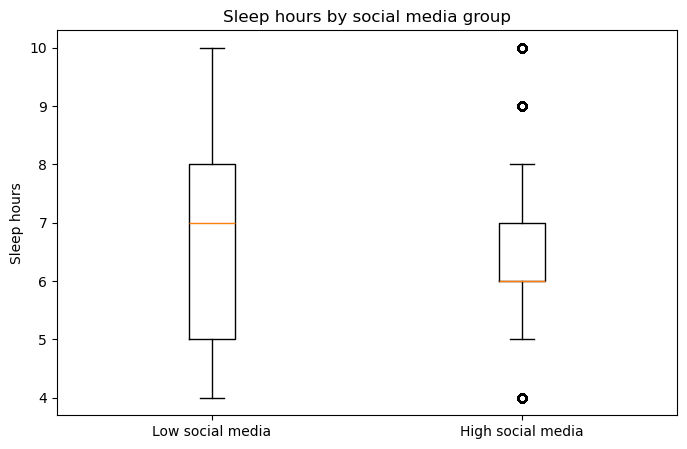

In [13]:
#Cell 11: boxplot för sömn i låg vs hög social media-grupp
plt.figure(figsize=(8, 5))
plt.boxplot([low_social, high_social], labels=["Low social media", "High social media"])
plt.title("Sleep hours by social media group")
plt.ylabel("Sleep hours")
plt.show()

In [15]:
#Cell 12: Shapiro-test för normalfördelning
#OBS: Shapiro är känsligt vid stora stickprov, så använd det tillsammans med histogram/boxplot.
stat_low, p_low = shapiro(low_social.sample(min(len(low_social), 5000), random_state=42))
stat_high, p_high = shapiro(high_social.sample(min(len(high_social), 5000), random_state=42))

print("Shapiro p-value low social:", p_low)
print("Shapiro p-value high social:", p_high)

Shapiro p-value low social: 1.3841190577354726e-27
Shapiro p-value high social: 3.3570297669986525e-40


In [16]:
#Cell 13: Levene-test för homogenitet av varians
stat_levene, p_levene = levene(low_social, high_social)

print("Levene p-value:", p_levene)

Levene p-value: 1.8327988970600278e-09


In [17]:
#Cell 14: välj test beroende på antaganden
if p_low > 0.05 and p_high > 0.05 and p_levene > 0.05:
    t_stat, p_value_group = ttest_ind(low_social, high_social)
    print("Chosen test: Independent t-test")
    print("t-statistic:", t_stat)
    print("p-value:", p_value_group)
else:
    u_stat, p_value_group = mannwhitneyu(low_social, high_social, alternative="two-sided")
    print("Chosen test: Mann-Whitney U")
    print("U-statistic:", u_stat)
    print("p-value:", p_value_group)

Chosen test: Mann-Whitney U
U-statistic: 12814491.5
p-value: 0.0028796568315701725
